In [1]:
import sys, os
import jax
from jax import numpy as jnp

import matplotlib, matplotlib.pyplot as plt
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

print( f"{jax.__version__=}" )

jax.__version__='0.6.0'


In [2]:
sys.path.append("../")
from csstlab_jax import Emulator as Emulator_jax

emu_jax = Emulator_jax()

### 
### basis spectrum as function of cosmological parameters 
### 

In [3]:
karr = jnp.logspace(-3, 0, 200)   ## wavenumber [h/Mpc]
zarr = [ 1, 2, 3, ]               ## redshift
emu_jax.set_k_and_z(karr, zarr)
emu_jax.set_derivative()      ## take times to pre-compile the derivative function

#  Omega_b, Omega_m, h, n_s, 1e9 A_s, w_0, w_a, M_\nu 
params = [ 0.048, 0.31, 0.67, 0.9665, 2.105, -0.9, 0.1, 0.1, ]
pk_ij = emu_jax(params)

print( pk_ij.shape )

(21, 3, 200)


### 
### basis spectrum derivative w.r.t the cosmological parameters 
### e.g.
### $\quad$ 1-st derivative $\;\frac{ \partial P_{ij} }{ \partial\alpha }$ w.r.t  $\;\alpha = \Omega_m$
### $\quad$ 2-nd derivative $\;\frac{ \partial^2 P_{ij} }{ \partial\alpha\partial\beta }$ w.r.t  $\;(\alpha, \beta) = (\Omega_m, \Omega_b)$
### 

In [4]:
## derivative parameters position
dp = 0            ## Omega_m
dp1, dp2 = 0, 1   ## Omega_m, Omega_b

## JAX differential
%time pk_ij = emu_jax(params)
%time pk_ij_deri  = emu_jax.pkij_diff(*params, dp)
%time pk_ij_deri2 = emu_jax.pkij_diff2(*params, dp1, dp2)

## finite difference 
%time pk_ij_deri_finite  = emu_jax.pkij_finiteDiff(*params, dp, eps=0.02, )
%time pk_ij_deri2_finite = emu_jax.pkij_finiteDiff2(*params, dp1, dp2, eps=0.02, )

print( pk_ij_deri.shape )
print( pk_ij_deri2.shape )

CPU times: user 333 ms, sys: 6.73 ms, total: 339 ms
Wall time: 310 ms
CPU times: user 540 ms, sys: 11 ms, total: 551 ms
Wall time: 501 ms
CPU times: user 883 ms, sys: 69.8 ms, total: 952 ms
Wall time: 883 ms
CPU times: user 1.7 s, sys: 19.4 ms, total: 1.72 s
Wall time: 1.64 s
CPU times: user 1.42 s, sys: 25.3 ms, total: 1.45 s
Wall time: 1.42 s
(21, 3, 200)
(21, 3, 200)


### 
### **Figure** : basis spectrum in the `JAX` framework
### 

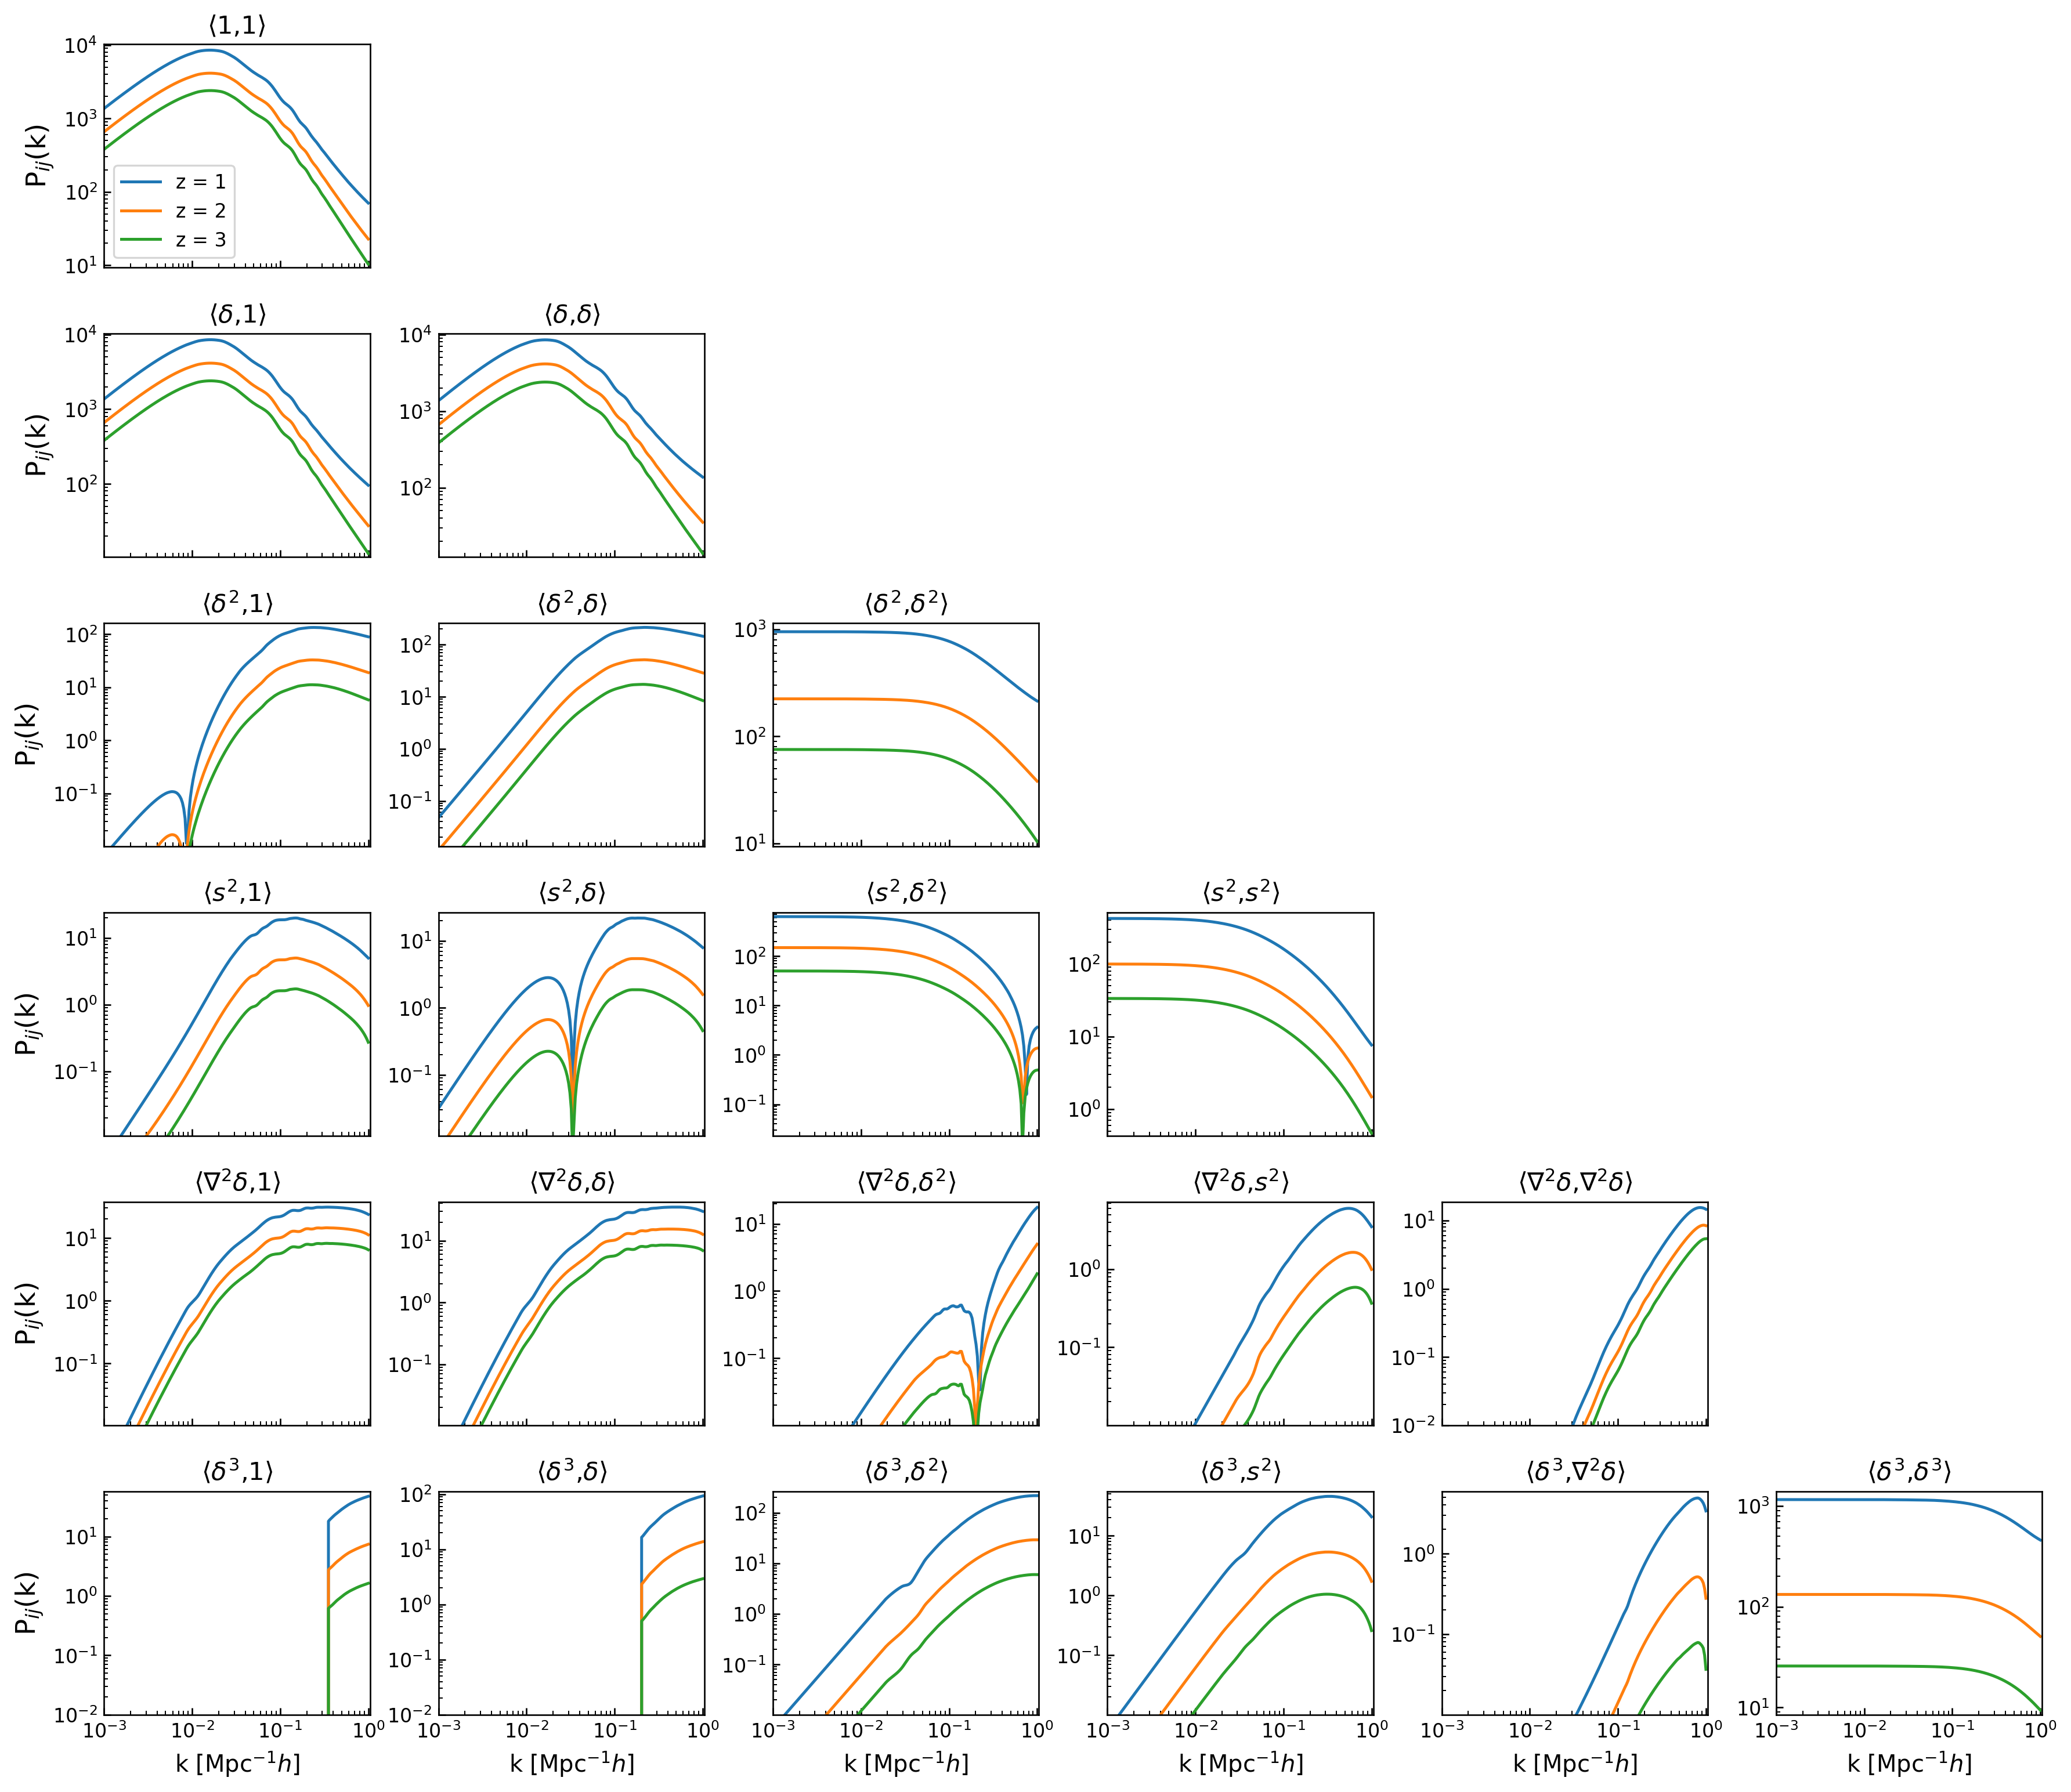

In [5]:
labels = [
    "1", 
    r"$\delta$", 
    r"$\delta^2$", 
    r"$s^2$", 
    r"$\nabla^2\delta$", 
    r"$\delta^3$", 
]

iz = 0
n = 6
fig, axes = plt.subplots(n, n, dpi=120, figsize=(15, 13), sharex=True, )
ipk = -1
for j in range(n):
    for i in range(n):
        if i < j: axes[i,j].axis('off') ; continue
        ipk += 1
        for iz in range(3):
            axes[i,j].loglog( karr, jnp.abs(pk_ij[ipk, iz,]), c=f"C{iz}", label=f"z = {zarr[iz]}" )
        
        vmin, vmax = jnp.abs(pk_ij[ipk]).min(), jnp.abs(pk_ij[ipk]).max()
        axes[i,j].set_title( f'⟨{labels[i]},{labels[j]}⟩', fontsize=13)
        axes[i,j].set_xlim( 1e-3, 1.05 )
        axes[i,j].set_ylim( vmin*0.9+1e-2, vmax*1.2 )
for i in range(n):
    axes[-1,i].set_xlabel(r"k [Mpc$^{-1}h$]", fontsize=12, )
    axes[i, 0].set_ylabel("P$_{ij}$(k)", fontsize=14, )
axes[0,0].legend(fontsize=10)
plt.tight_layout( h_pad=0.8, w_pad=0, )
plt.show()

### 
### **Figure** : 1-st `JAX` derivative basis power spectrum, $\;\frac{ \partial P_{ij} }{ \partial\alpha }$, with $\;\alpha = \Omega_m$
### comparison with the finite difference method
### 

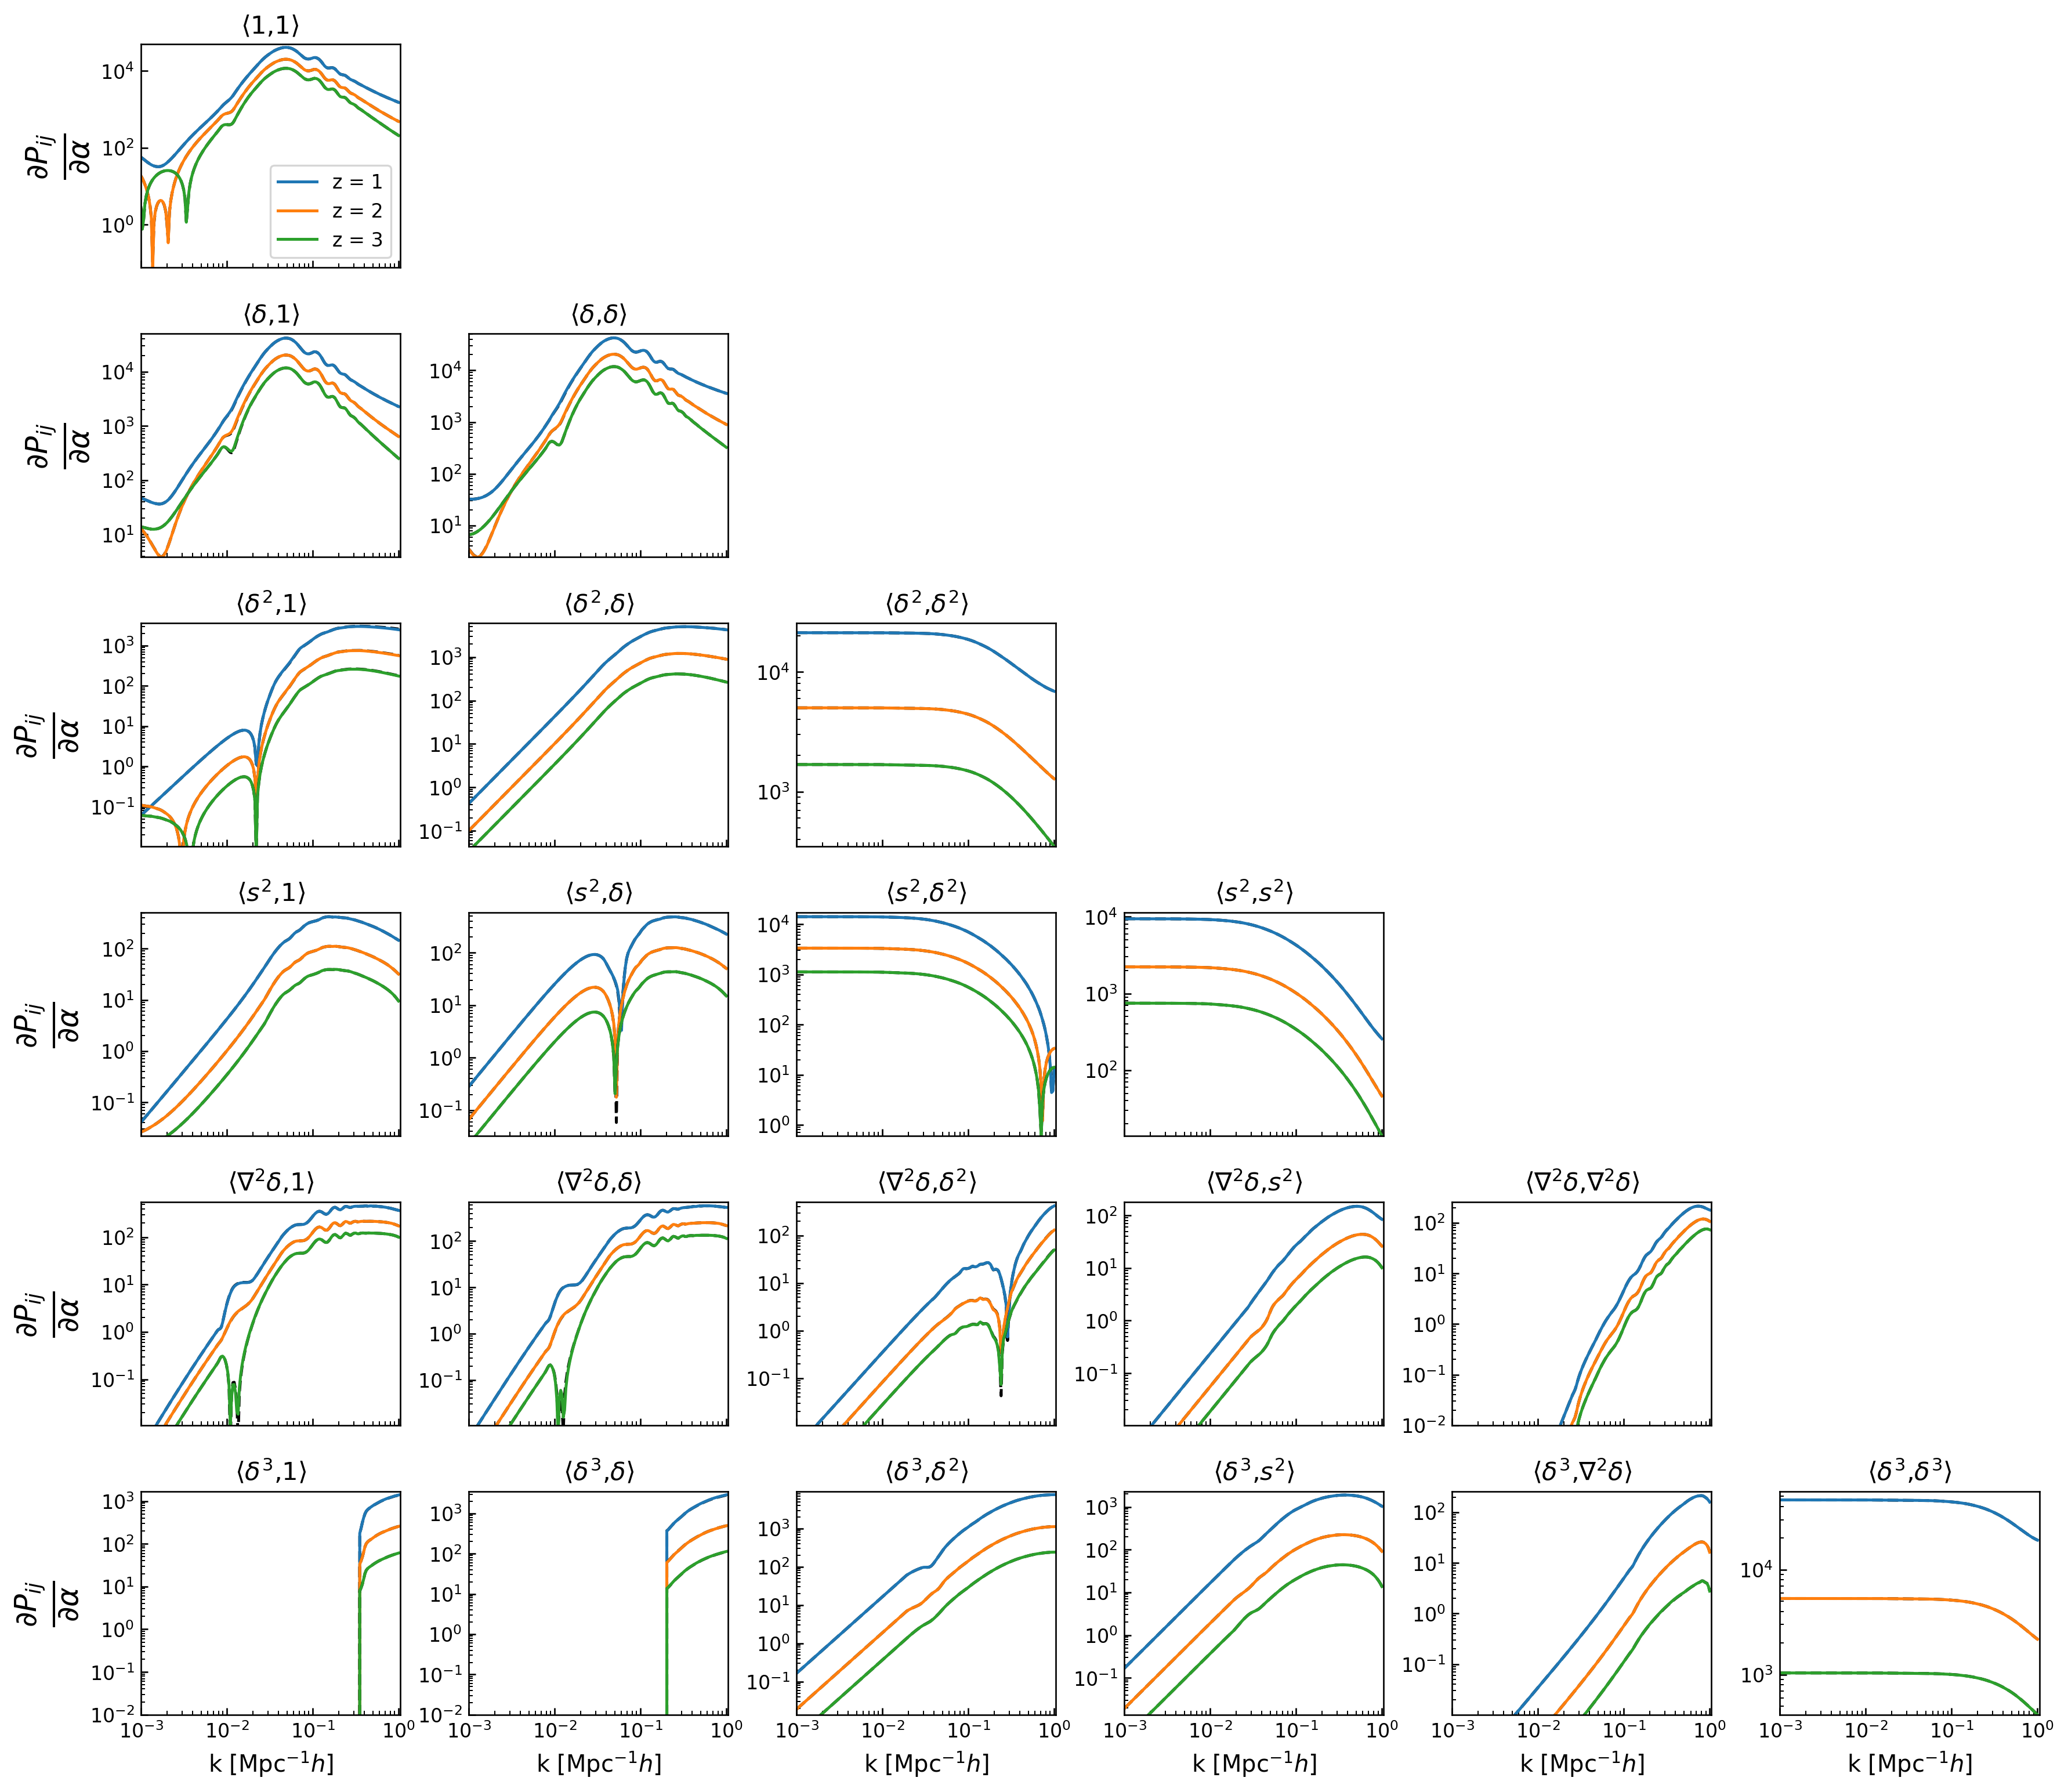

In [6]:
iz = 0
n = 6
fig, axes = plt.subplots(n, n, dpi=120, figsize=(15, 13), sharex=True, )
ipk = -1
for j in range(n):
    for i in range(n):
        if i < j: axes[i,j].axis('off') ; continue
        ipk += 1
        for iz in range(3):
            axes[i,j].loglog( karr, jnp.abs(pk_ij_deri_finite[ipk, iz,]), c=f"k", ls='--' )
            axes[i,j].loglog( karr, jnp.abs(pk_ij_deri[ipk, iz,]), c=f"C{iz}", label=f"z = {zarr[iz]}" )
        
        vmin, vmax = jnp.abs(pk_ij_deri[ipk]).min(), jnp.abs(pk_ij_deri[ipk]).max()
        axes[i,j].set_title( f'⟨{labels[i]},{labels[j]}⟩', fontsize=13)
        axes[i,j].set_xlim( 1e-3, 1.05 )
        axes[i,j].set_ylim( vmin+1e-2, vmax*1.2 )
for i in range(n):
    axes[-1,i].set_xlabel(r"k [Mpc$^{-1}h$]", fontsize=12, )
    axes[i, 0].set_ylabel( r"$\frac{ \partial P_{ij} }{ \partial\alpha }$", fontsize=22, )
axes[0,0].legend(fontsize=10)
plt.tight_layout( h_pad=0.8, w_pad=0, )
plt.show()

### 
### **Figure** : 2-nd `JAX` derivative basis power spectrum, $\;\frac{ \partial^2 P_{ij} }{ \partial\alpha\partial\beta }$, with $\;(\alpha, \beta) = (\Omega_m, \Omega_b)$
### comparison with the finite difference method
### 

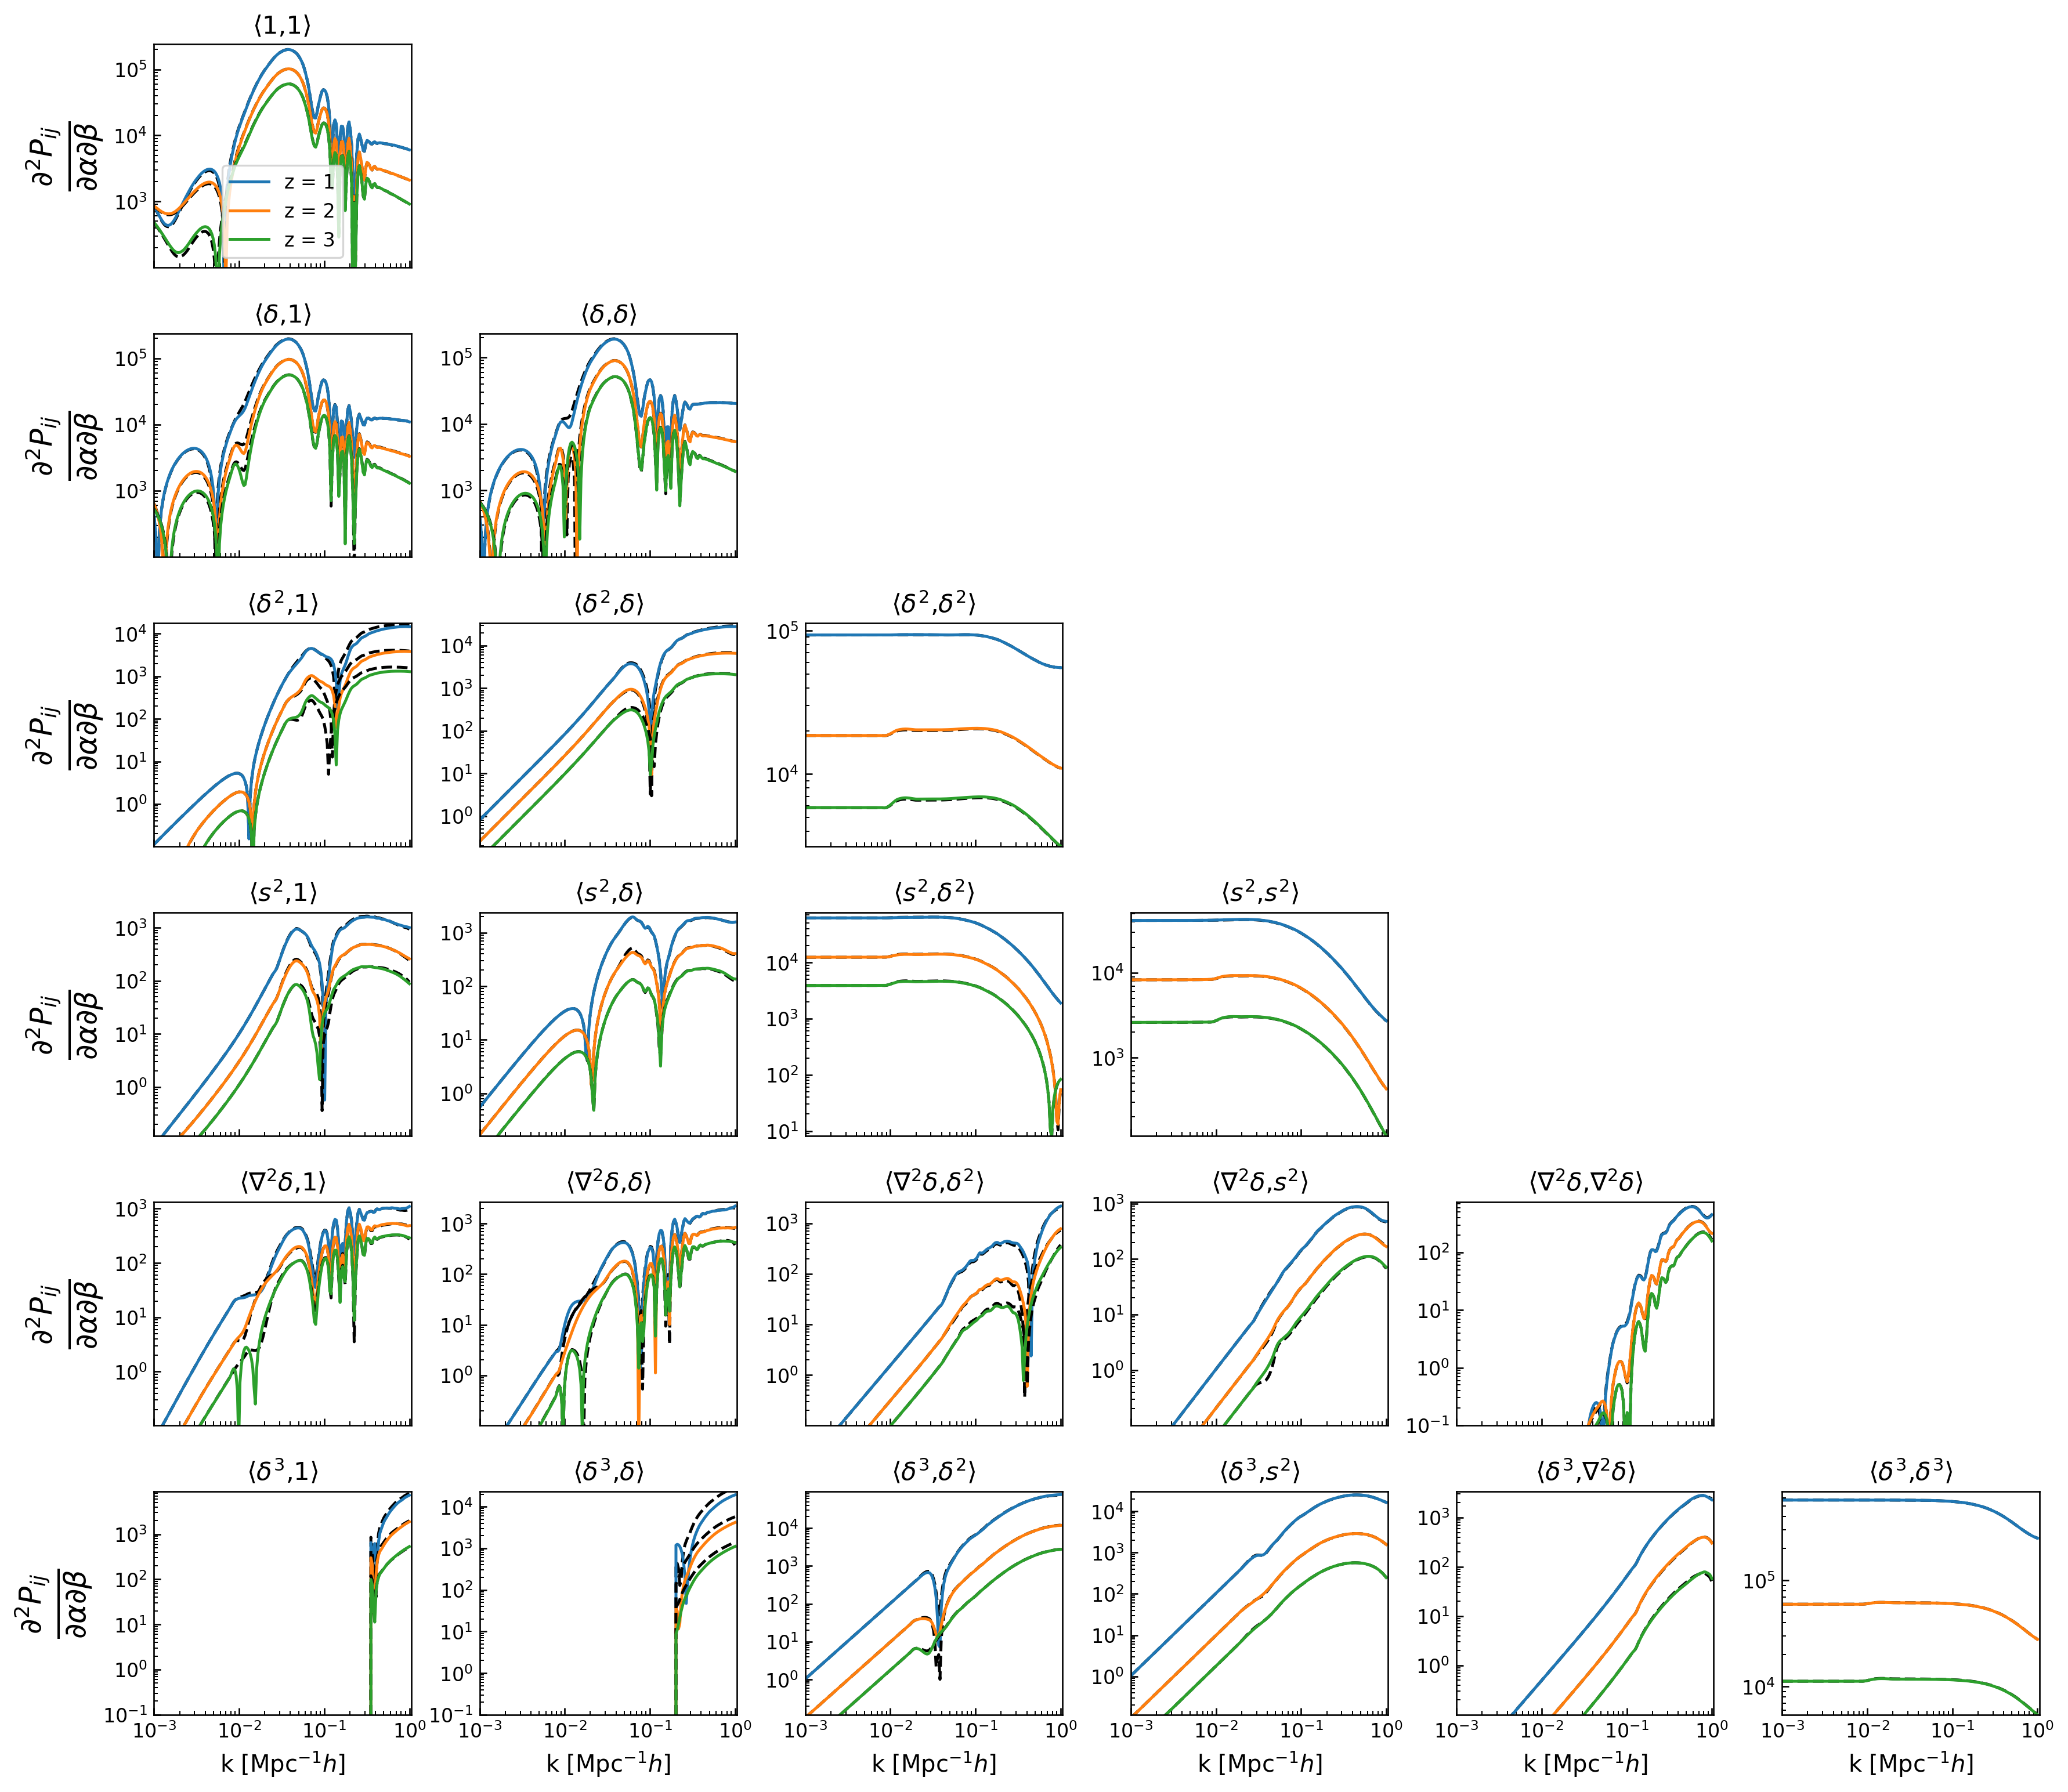

In [7]:
iz = 0
n = 6
fig, axes = plt.subplots(n, n, dpi=120, figsize=(15, 13), sharex=True, )
ipk = -1
for j in range(n):
    for i in range(n):
        if i < j: axes[i,j].axis('off') ; continue
        ipk += 1
        for iz in range(3):
            axes[i,j].loglog( karr, jnp.abs(pk_ij_deri2_finite[ipk, iz,]), c=f"k", ls='--' )
            axes[i,j].loglog( karr, jnp.abs(pk_ij_deri2[ipk, iz,]), c=f"C{iz}", label=f"z = {zarr[iz]}" )
        
        vmin, vmax = jnp.abs(pk_ij_deri2[ipk]).min(), jnp.abs(pk_ij_deri2[ipk]).max()
        if i<2 and j<2 : vmin = 100
        axes[i,j].set_title( f'⟨{labels[i]},{labels[j]}⟩', fontsize=13)
        axes[i,j].set_xlim( 1e-3, 1.05 )
        axes[i,j].set_ylim( vmin+1e-1, vmax*1.2 )
for i in range(n):
    axes[-1,i].set_xlabel( r"k [Mpc$^{-1}h$]", fontsize=12, )
    axes[i, 0].set_ylabel( r"$\frac{ \partial^2 P_{ij} }{ \partial\alpha\partial\beta }$", fontsize=22, )
axes[0,0].legend(fontsize=10)
plt.tight_layout( h_pad=0.8, w_pad=0, )
plt.show()

### 
### **Figure** : 2-nd `JAX` derivative basis power spectrum w.r.t Dark Energy parameters, $\;\frac{ \partial^2 P_{ij} }{ \partial\alpha\partial\beta }$, with $\;(\alpha, \beta) = (w_0, w_a)$
### comparison with the finite difference method
### 

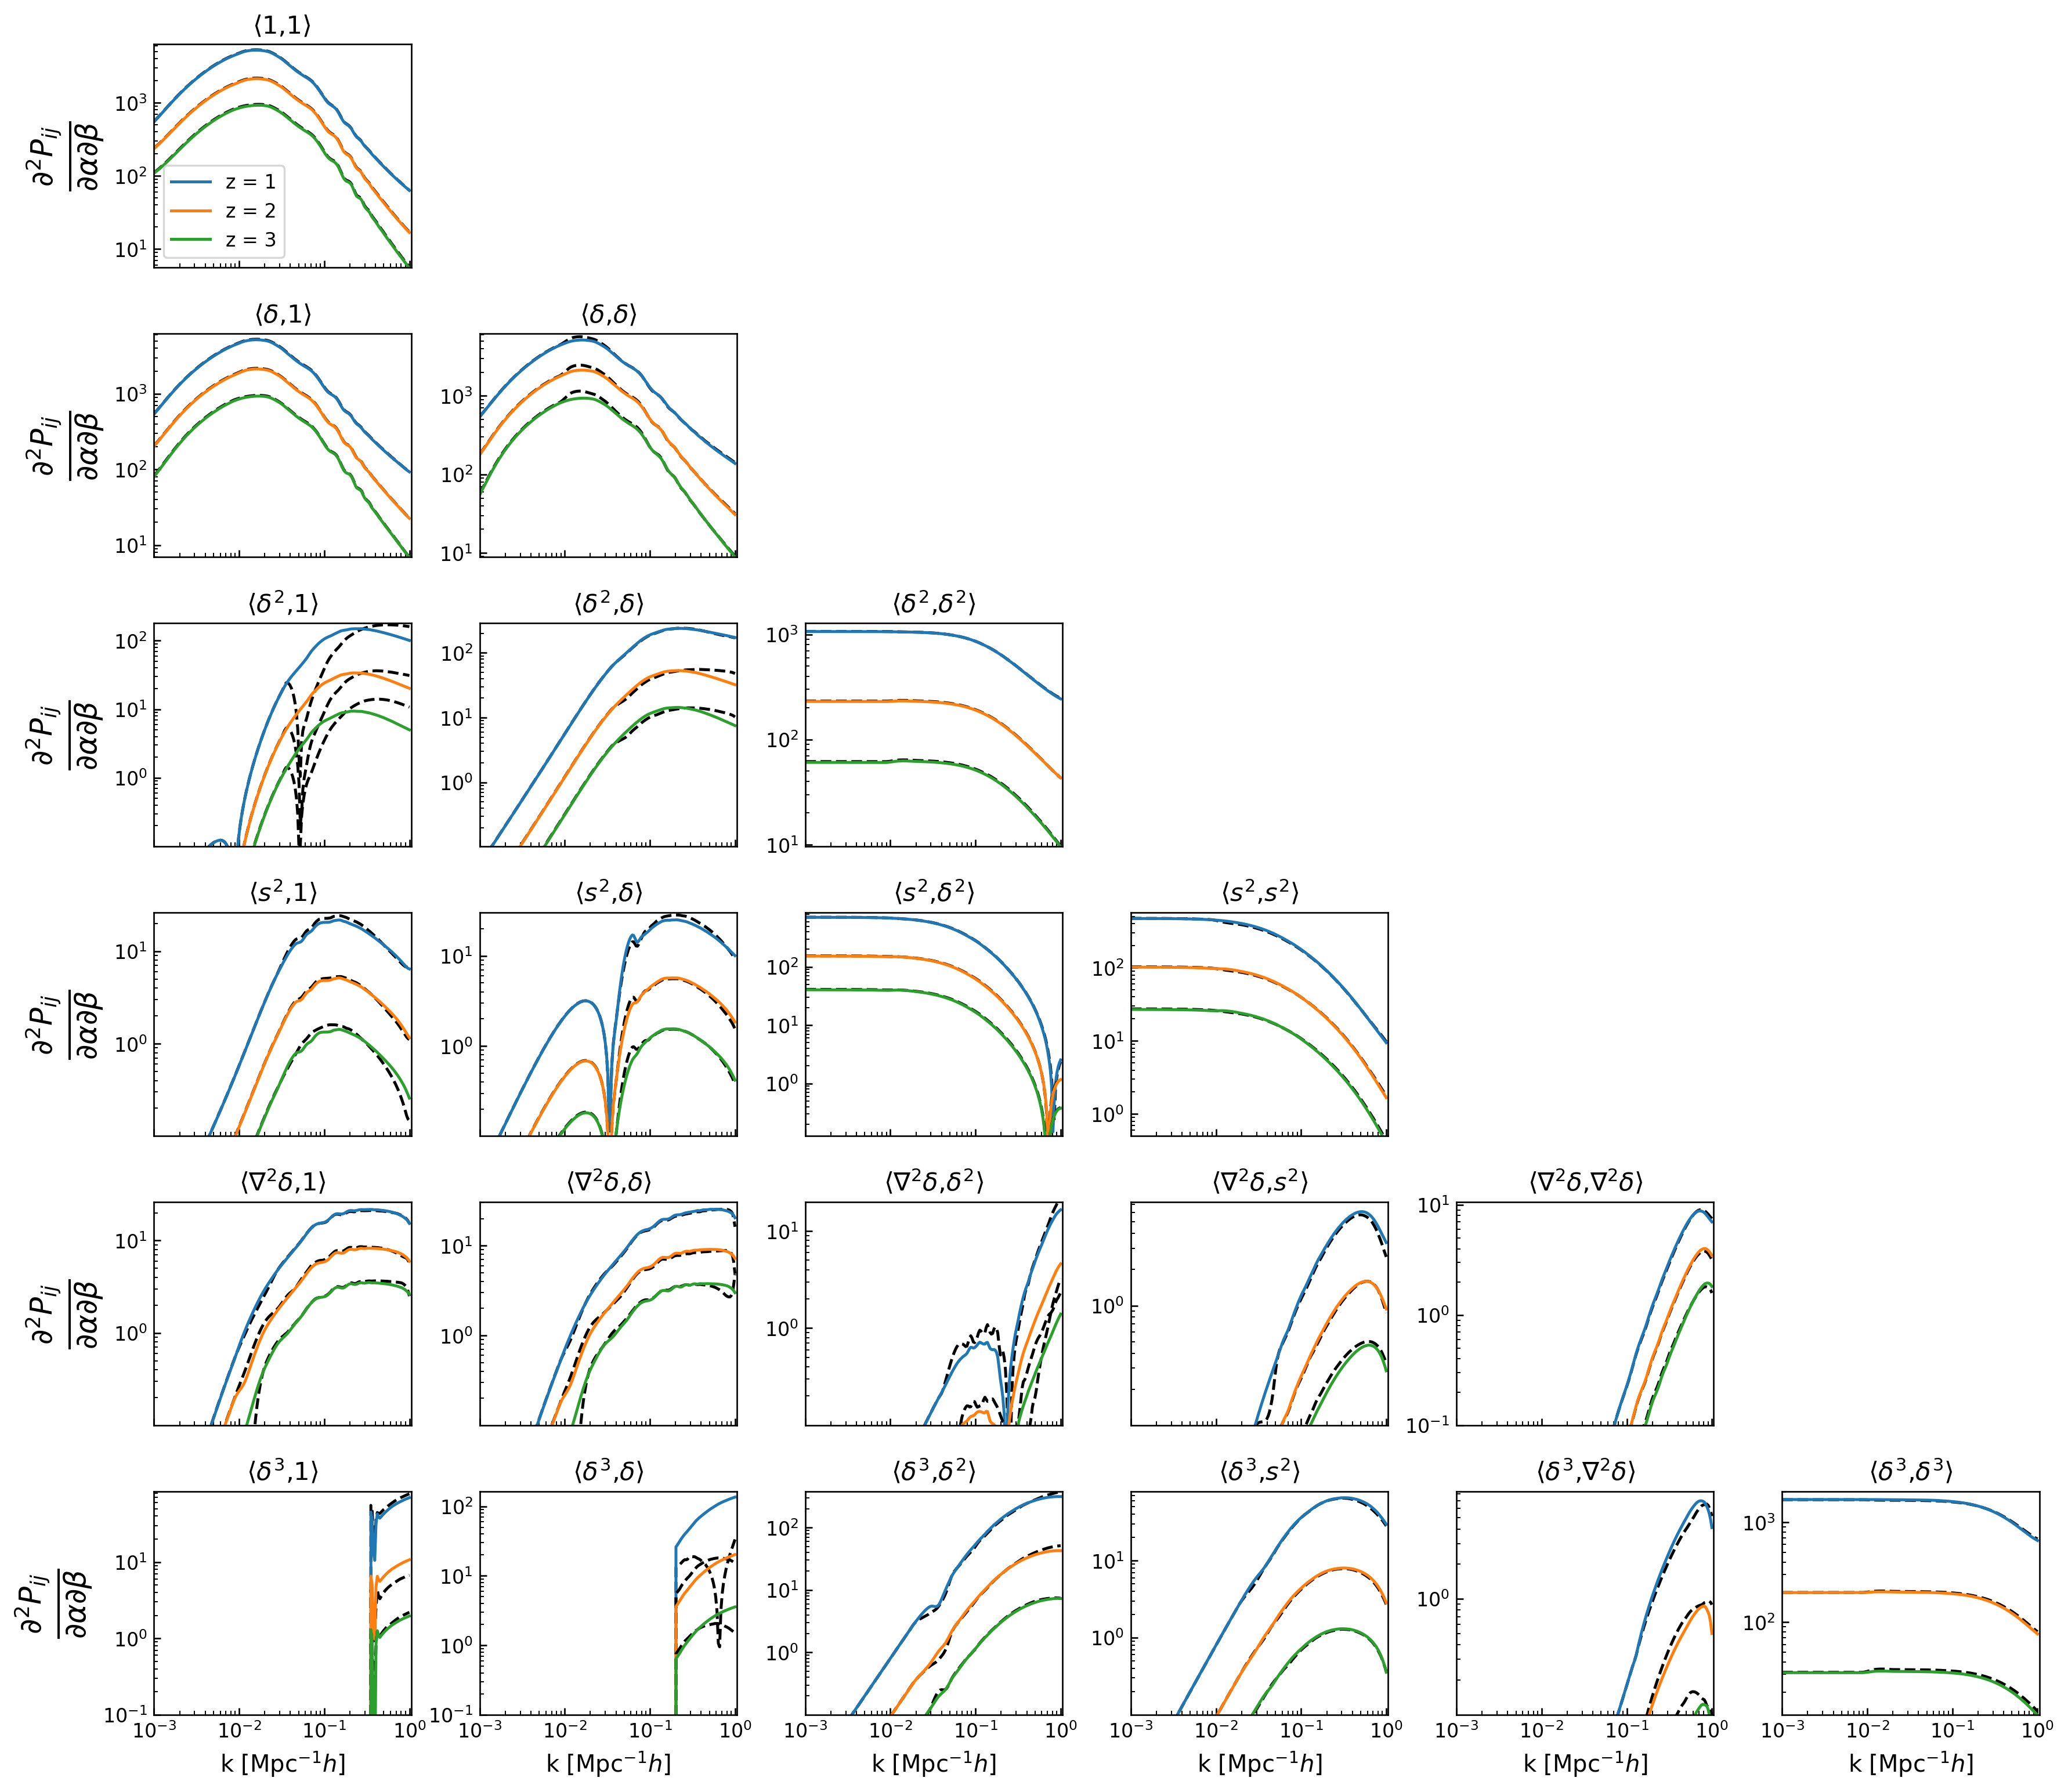

In [10]:
## derivative parameters position
Iparam = 5            ## w_0
Iparam1, Iparam2 = 5, 6   ## w_0, w_a

## JAX differential
pk_ij_deri2 = emu_jax.pkij_diff2(*params, Iparam1, Iparam2)

## finite difference 
pk_ij_deri2_finite = emu_jax.pkij_finiteDiff2(*params, Iparam1, Iparam2, eps=0.05, )


iz = 0
n = 6
fig, axes = plt.subplots(n, n, dpi=120, figsize=(15, 13), sharex=True, )
ipk = -1
for j in range(n):
    for i in range(n):
        if i < j: axes[i,j].axis('off') ; continue
        ipk += 1
        for iz in range(3):
            axes[i,j].loglog( karr, jnp.abs(pk_ij_deri2_finite[ipk, iz,]), c=f"k", ls='--' )
            axes[i,j].loglog( karr, jnp.abs(pk_ij_deri2[ipk, iz,]), c=f"C{iz}", label=f"z = {zarr[iz]}" )
        
        vmin, vmax = jnp.abs(pk_ij_deri2[ipk]).min(), jnp.abs(pk_ij_deri2[ipk]).max()
        axes[i,j].set_title( f'⟨{labels[i]},{labels[j]}⟩', fontsize=13)
        axes[i,j].set_xlim( 1e-3, 1.05 )
        axes[i,j].set_ylim( vmin+1e-1, vmax*1.2 )
for i in range(n):
    axes[-1,i].set_xlabel( r"k [Mpc$^{-1}h$]", fontsize=12, )
    axes[i, 0].set_ylabel( r"$\frac{ \partial^2 P_{ij} }{ \partial\alpha\partial\beta }$", fontsize=22, )
axes[0,0].legend(fontsize=10)
plt.tight_layout( h_pad=0.8, w_pad=0, )
plt.show()

### 
### **Figure** : 2-nd `JAX` derivative basis power spectrum w.r.t neutrino parameters, $\;\frac{ \partial^2 P_{ij} }{ \partial\alpha\partial\beta }$, with $\;(\alpha, \beta) = (\Omega_m, M_\nu)$
### comparison with the finite difference method
### 

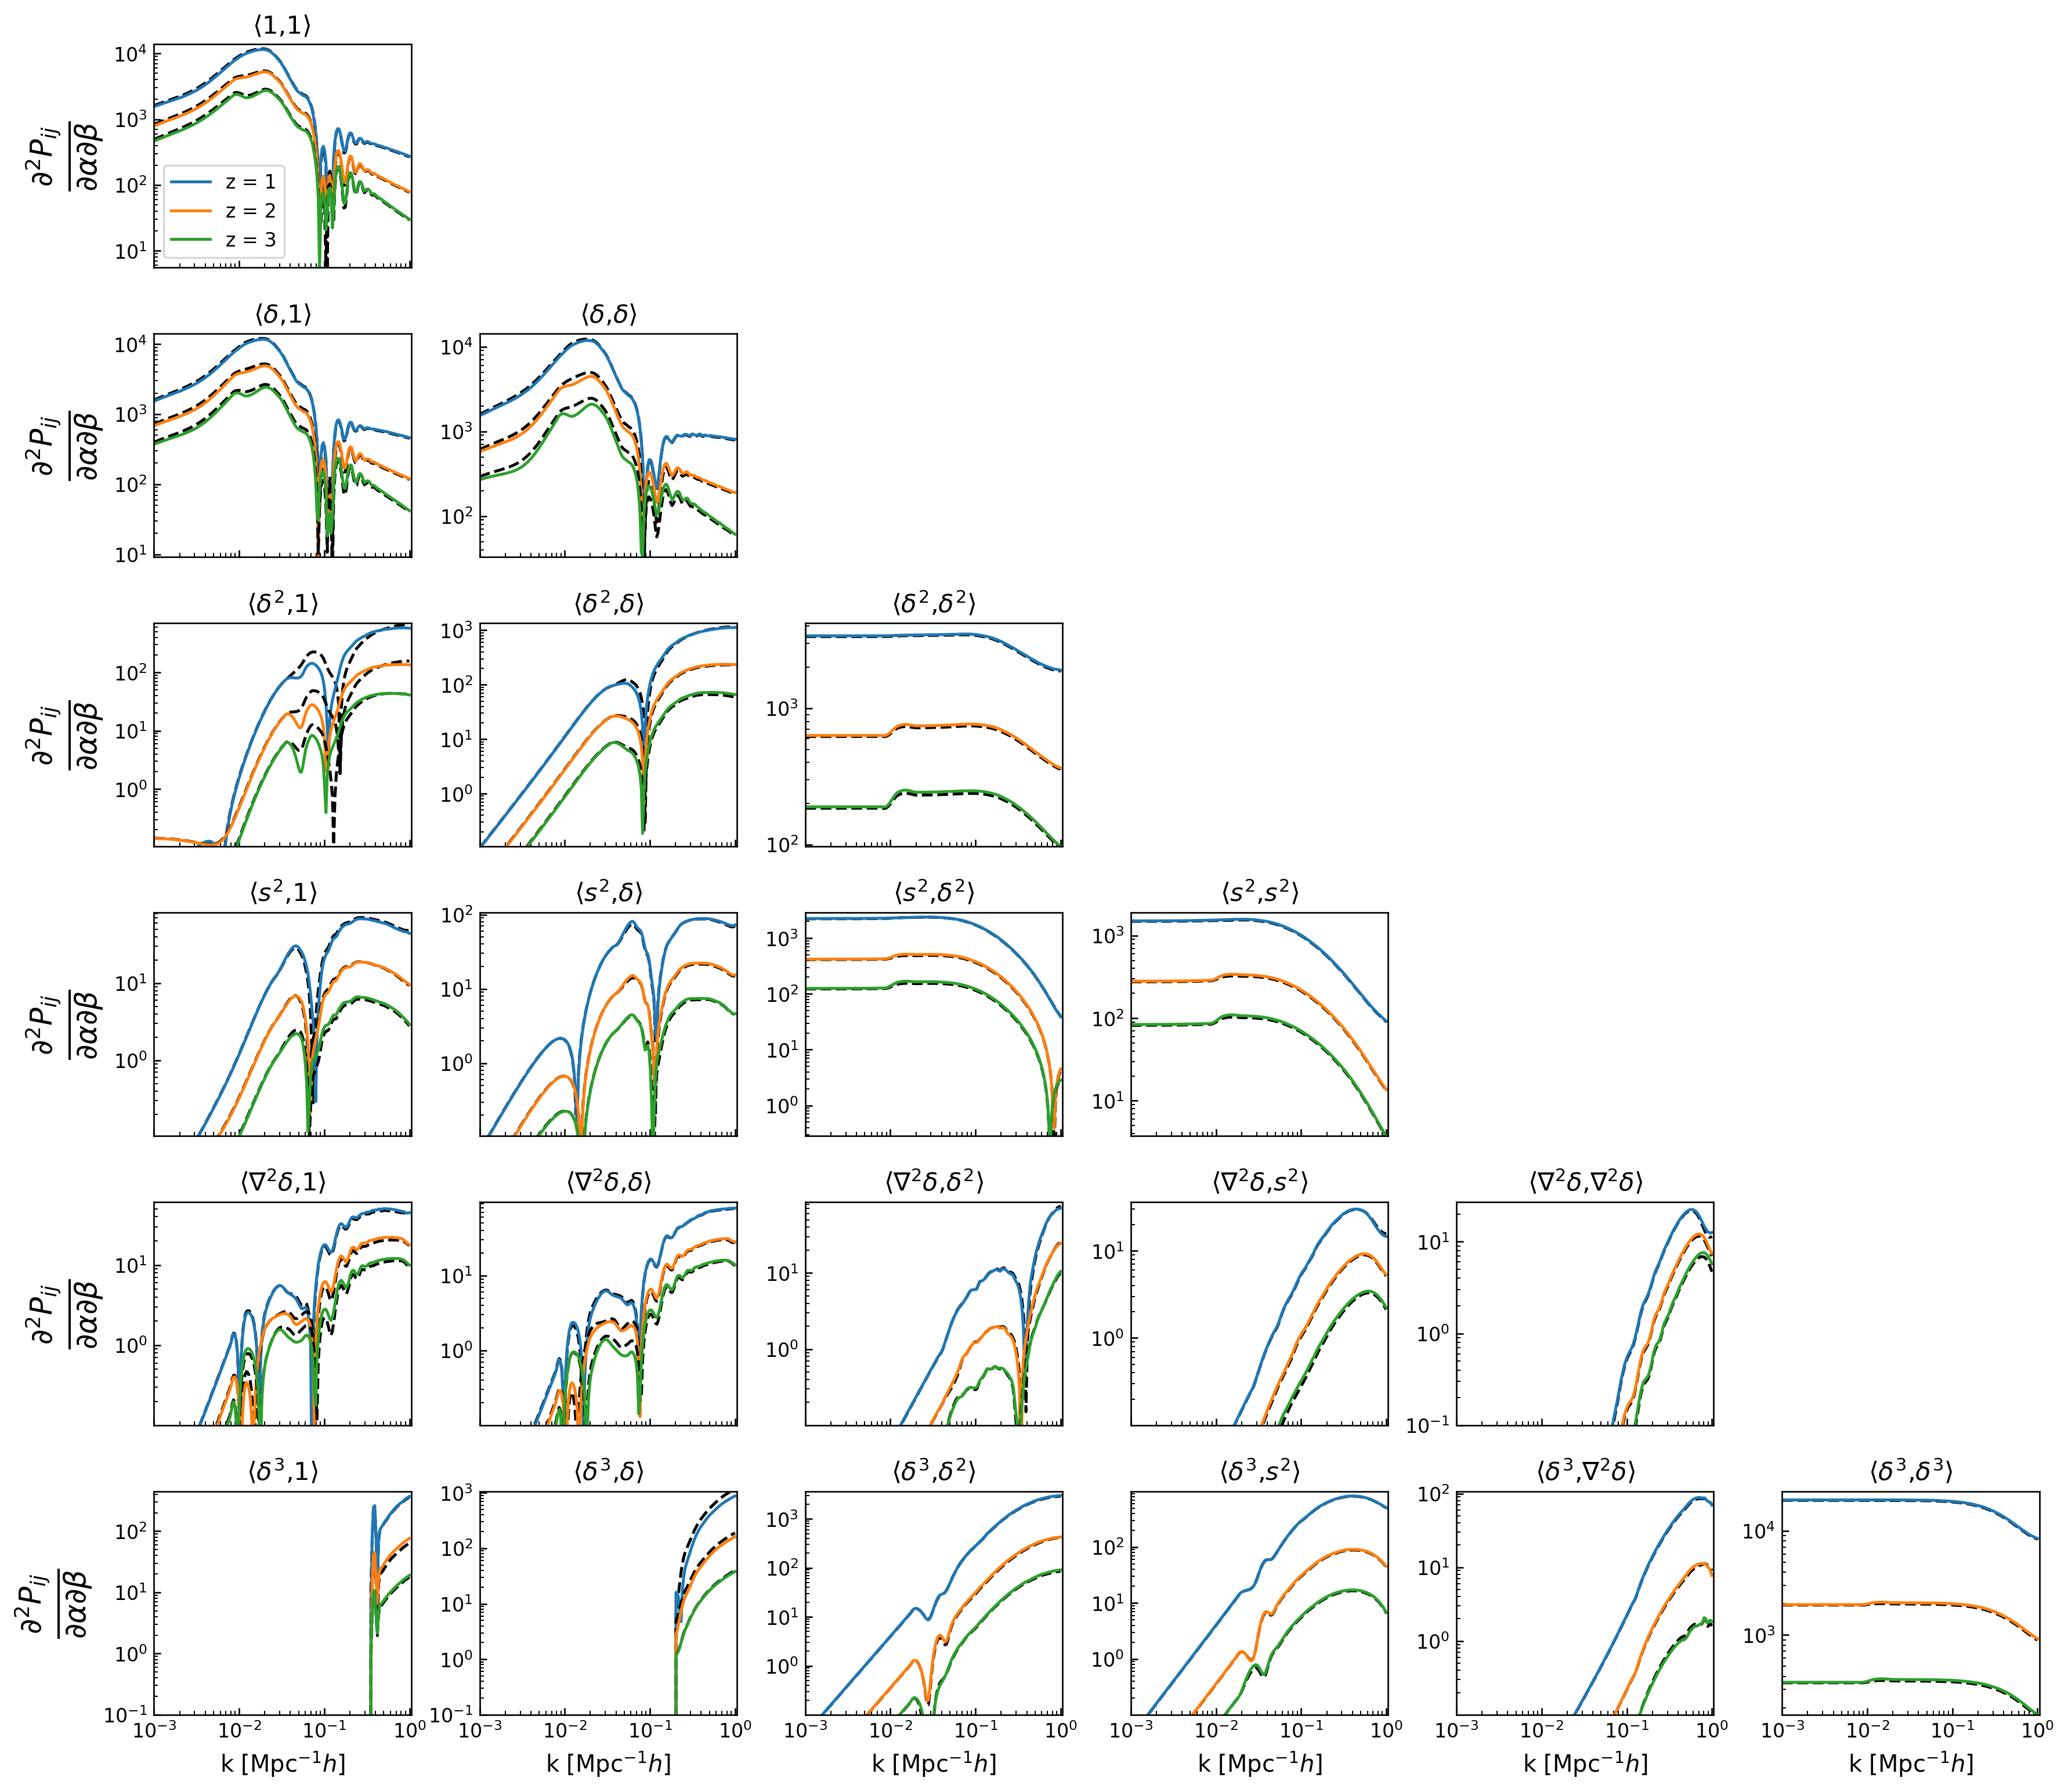

In [11]:
## derivative parameters position
Iparam1, Iparam2 = 1, 7   ## Omega_m, M_nu

## JAX differential
pk_ij_deri2 = emu_jax.pkij_diff2(*params, Iparam1, Iparam2)

## finite difference 
pk_ij_deri2_finite = emu_jax.pkij_finiteDiff2(*params, Iparam1, Iparam2, eps=0.08, )


iz = 0
n = 6
fig, axes = plt.subplots(n, n, dpi=120, figsize=(15, 13), sharex=True, )
ipk = -1
for j in range(n):
    for i in range(n):
        if i < j: axes[i,j].axis('off') ; continue
        ipk += 1
        for iz in range(3):
            axes[i,j].loglog( karr, jnp.abs(pk_ij_deri2_finite[ipk, iz,]), c=f"k", ls='--' )
            axes[i,j].loglog( karr, jnp.abs(pk_ij_deri2[ipk, iz,]), c=f"C{iz}", label=f"z = {zarr[iz]}" )
        
        vmin, vmax = jnp.abs(pk_ij_deri2[ipk]).min(), jnp.abs(pk_ij_deri2[ipk]).max()
        axes[i,j].set_title( f'⟨{labels[i]},{labels[j]}⟩', fontsize=13)
        axes[i,j].set_xlim( 1e-3, 1.05 )
        axes[i,j].set_ylim( vmin+1e-1, vmax*1.2 )
for i in range(n):
    axes[-1,i].set_xlabel( r"k [Mpc$^{-1}h$]", fontsize=12, )
    axes[i, 0].set_ylabel( r"$\frac{ \partial^2 P_{ij} }{ \partial\alpha\partial\beta }$", fontsize=22, )
axes[0,0].legend(fontsize=10)
plt.tight_layout( h_pad=0.8, w_pad=0, )
plt.show()